In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g) # the embedding table
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [7]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X and Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer activation
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 27.8817
  10000/200000: 2.8138
  20000/200000: 2.5218
  30000/200000: 2.7874
  40000/200000: 2.0334
  50000/200000: 2.6237
  60000/200000: 2.3289
  70000/200000: 2.0826
  80000/200000: 2.2784
  90000/200000: 2.2252
 100000/200000: 2.0428
 110000/200000: 2.3121
 120000/200000: 2.0570
 130000/200000: 2.4546
 140000/200000: 2.2233
 150000/200000: 2.1551
 160000/200000: 2.0597
 170000/200000: 1.7981
 180000/200000: 2.0194
 190000/200000: 1.7459


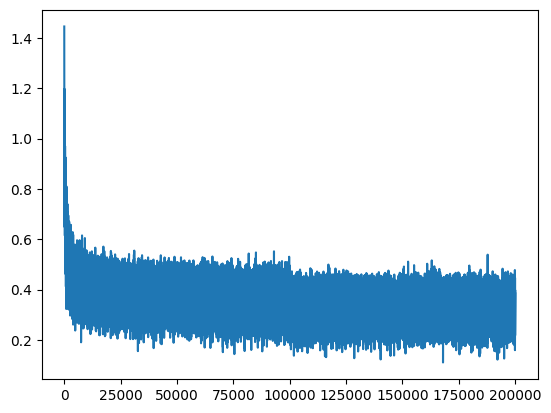

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.1267659664154053
val 2.1697638034820557


In [10]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix] # crop and append
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word

dexzerioullus.
rochi.
ahnell.
imittain.
lucan.
kaida.
samiyah.
javarii.
tai.
moziellah.
jacoredo.
kaley.
maside.
enkavirshif.
bsellini.
gavtarlyn.
kasdra.
aneil.
pynn.
isa.


In [11]:
1/27.0

0.037037037037037035

In [12]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [14]:
# 4-dimensional example of the issue
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
probs, loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [15]:
# 4-dimensional example of the issue
logits = torch.tensor([0.0, 0.0, 5.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
probs, loss

(tensor([0.0066, 0.0066, 0.9802, 0.0066]), tensor(0.0200))

In [18]:
# 4-dimensional example of the issue
logits = torch.randn(4) * 10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([  7.2209,   6.1291, -26.0796, -11.2816]),
 tensor([7.4872e-01, 2.5128e-01, 2.5826e-15, 6.8991e-09]),
 tensor(33.5900))

In [19]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g) # the embedding table
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [20]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X and Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer activation
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 4.2326
  10000/200000: 2.1403
  20000/200000: 2.4720
  30000/200000: 2.5577
  40000/200000: 2.0154
  50000/200000: 2.4307
  60000/200000: 2.3385
  70000/200000: 2.0680
  80000/200000: 2.2665
  90000/200000: 2.1172
 100000/200000: 1.9299
 110000/200000: 2.0630
 120000/200000: 1.8901
 130000/200000: 2.3980
 140000/200000: 2.2826
 150000/200000: 2.1250
 160000/200000: 1.8469
 170000/200000: 1.7627
 180000/200000: 1.9119
 190000/200000: 1.8235


In [22]:
h

tensor([[ 0.9880,  0.9875, -0.5555,  ..., -1.0000,  1.0000,  1.0000],
        [-0.9973, -1.0000, -1.0000,  ...,  0.9994,  0.9825, -0.6707],
        [-1.0000,  0.8087, -1.0000,  ...,  0.1175, -0.9548, -0.8030],
        ...,
        [-0.9796, -0.9920, -1.0000,  ...,  0.9926, -0.4096,  0.9599],
        [ 0.9952,  0.9896,  1.0000,  ..., -0.9999, -1.0000,  0.9992],
        [-1.0000, -1.0000, -1.0000,  ...,  0.9967, -0.9869, -0.3506]],
       grad_fn=<TanhBackward0>)

In [23]:
h.view(-1).tolist()

[0.9880094528198242,
 0.9875064492225647,
 -0.5555408596992493,
 0.993529736995697,
 0.9999935030937195,
 0.9988082051277161,
 0.9999081492424011,
 0.9978215098381042,
 0.9914295673370361,
 0.5036572813987732,
 -0.5822046399116516,
 0.4274728298187256,
 0.9979358315467834,
 0.9456751346588135,
 -0.9863879680633545,
 -0.2783127725124359,
 0.9999998807907104,
 -0.9998005032539368,
 -1.0,
 0.9999983906745911,
 0.9999984502792358,
 0.9999909996986389,
 0.9999796152114868,
 0.9998359680175781,
 -0.9999411106109619,
 0.9999837279319763,
 -0.9128392338752747,
 0.9999542236328125,
 -0.15031735599040985,
 0.9999947547912598,
 -0.5196112394332886,
 -0.999990701675415,
 -0.9999995827674866,
 -0.9977129101753235,
 -0.9999921917915344,
 0.8406814932823181,
 -0.9465526342391968,
 -0.9970446825027466,
 0.6349307894706726,
 0.965907871723175,
 0.7439777255058289,
 -1.0,
 -0.9997416138648987,
 -1.0,
 -0.5458608865737915,
 -0.6123791337013245,
 -0.8139672875404358,
 -0.9999995827674866,
 1.0,
 -0.089870

(array([2141.,  135.,   90.,   60.,   83.,   75.,   37.,   41.,   29.,
          21.,   40.,   36.,   13.,   26.,   20.,   35.,   14.,   20.,
          21.,   31.,   10.,   25.,   18.,   14.,   17.,   20.,   26.,
          19.,   25.,   21.,   28.,   31.,   23.,   23.,   32.,   13.,
          15.,   33.,   26.,   30.,   34.,   31.,   24.,   44.,   43.,
          62.,   70.,   71.,  120., 2484.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

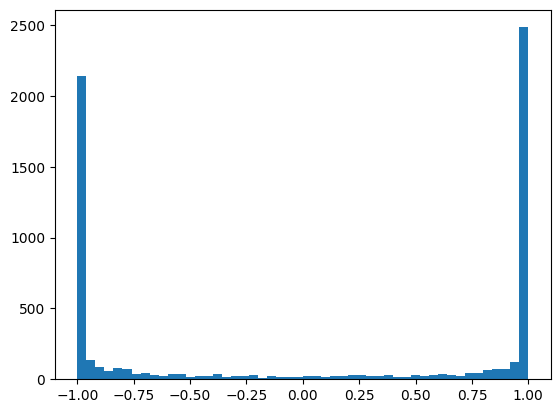

In [24]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   0.,   0.,   0.,   6.,   3.,   3.,  14.,  16.,  12.,  19.,
         49.,  76.,  70.,  95., 122., 159., 198., 232., 256., 269., 289.,
        338., 467., 467., 445., 367., 364., 309., 287., 297., 251., 187.,
        160., 121., 119.,  90.,  78.,  52.,  34.,  24.,  23.,  12.,   9.,
          6.,   3.,   0.,   0.,   0.,   1.]),
 array([-23.34061241, -22.3992696 , -21.45792679, -20.51658398,
        -19.57524117, -18.63389835, -17.69255554, -16.75121273,
        -15.80986992, -14.86852711, -13.9271843 , -12.98584148,
        -12.04449867, -11.10315586, -10.16181305,  -9.22047024,
         -8.27912743,  -7.33778461,  -6.3964418 ,  -5.45509899,
         -4.51375618,  -3.57241337,  -2.63107056,  -1.68972775,
         -0.74838493,   0.19295788,   1.13430069,   2.0756435 ,
          3.01698631,   3.95832912,   4.89967194,   5.84101475,
          6.78235756,   7.72370037,   8.66504318,   9.60638599,
         10.54772881,  11.48907162,  12.43041443,  13.37175724,
         14.313100

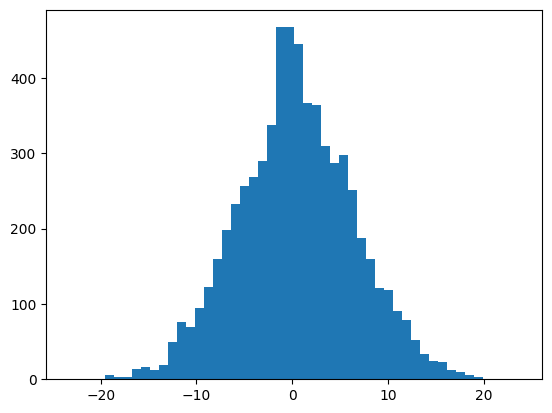

In [25]:
plt.hist(hpreact.view(-1).tolist(), 50)

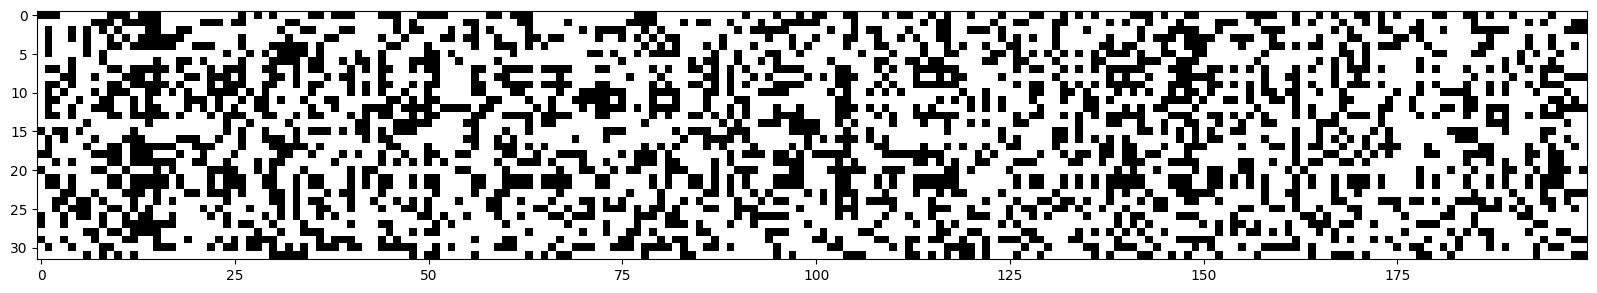

In [26]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [28]:
# MLP revisited
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)  # the embedding table
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.1
b1 = torch.randn(n_hidden, generator=g) * 0.02
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
# print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact)  # hidden layer activation
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 3.3071
  10000/200000: 2.1872
  20000/200000: 2.2843
  30000/200000: 2.4295
  40000/200000: 1.9513
  50000/200000: 2.4195
  60000/200000: 2.3137
  70000/200000: 2.1363
  80000/200000: 2.3086
  90000/200000: 2.1546
 100000/200000: 1.8520
 110000/200000: 2.1916
 120000/200000: 1.8928
 130000/200000: 2.3152
 140000/200000: 2.3435
 150000/200000: 2.1666
 160000/200000: 1.9035
 170000/200000: 1.7959
 180000/200000: 2.0394
 190000/200000: 1.8576


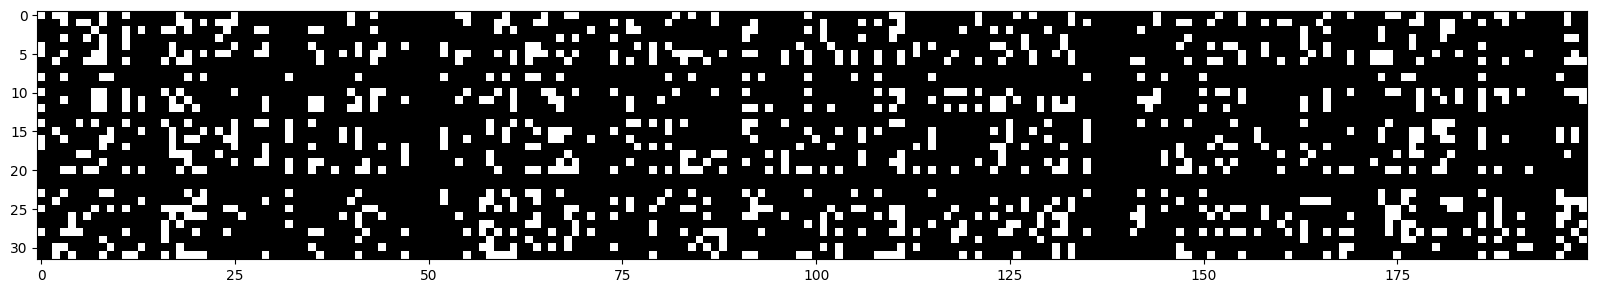

In [29]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

(array([801., 164.,  94., 106.,  77.,  68.,  55.,  44.,  49.,  44.,  59.,
         53.,  39.,  30.,  63.,  46.,  57.,  54.,  78.,  69.,  92.,  90.,
        143., 244., 567., 559., 283., 138., 109.,  85.,  69.,  55.,  43.,
         51.,  53.,  41.,  38.,  42.,  62.,  46.,  59.,  48.,  64.,  54.,
         69.,  74.,  80., 128., 145., 819.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

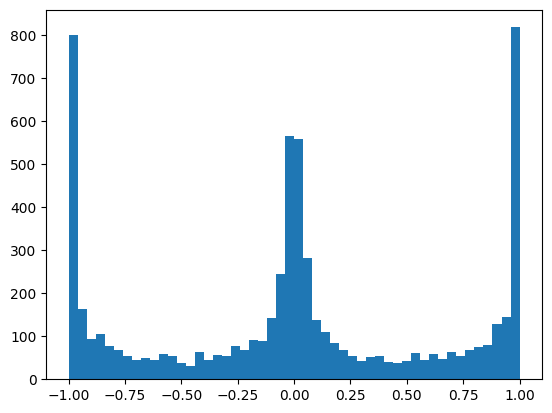

In [30]:
h.view(-1).tolist()
plt.hist(h.view(-1).tolist(), 50)

(array([2.000e+00, 1.000e+00, 2.000e+00, 5.000e+00, 0.000e+00, 3.000e+00,
        6.000e+00, 9.000e+00, 1.000e+01, 1.000e+01, 1.300e+01, 2.700e+01,
        2.600e+01, 5.800e+01, 5.600e+01, 6.200e+01, 1.070e+02, 9.600e+01,
        1.310e+02, 1.420e+02, 1.860e+02, 2.190e+02, 2.480e+02, 3.250e+02,
        9.940e+02, 1.813e+03, 3.680e+02, 2.760e+02, 2.110e+02, 1.750e+02,
        1.770e+02, 1.470e+02, 1.110e+02, 7.300e+01, 7.000e+01, 5.000e+01,
        4.200e+01, 4.100e+01, 2.800e+01, 1.700e+01, 1.400e+01, 1.700e+01,
        1.000e+01, 7.000e+00, 2.000e+00, 5.000e+00, 3.000e+00, 2.000e+00,
        1.000e+00, 2.000e+00]),
 array([-9.9022665 , -9.50739664, -9.11252678, -8.71765692, -8.32278706,
        -7.92791719, -7.53304733, -7.13817747, -6.74330761, -6.34843775,
        -5.95356789, -5.55869802, -5.16382816, -4.7689583 , -4.37408844,
        -3.97921858, -3.58434872, -3.18947886, -2.79460899, -2.39973913,
        -2.00486927, -1.60999941, -1.21512955, -0.82025969, -0.42538982,
        -0.

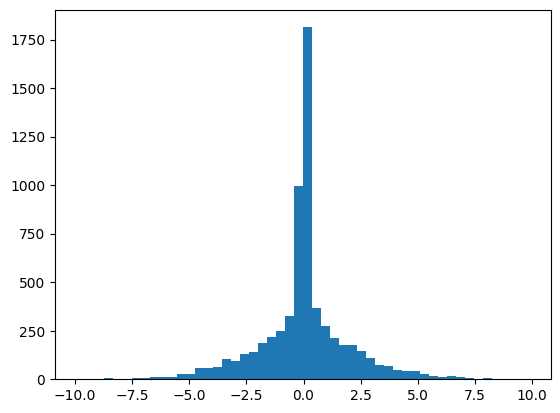

In [31]:
plt.hist(hpreact.view(-1).tolist(), 50)

In [32]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.0599000453948975
val 2.114264965057373


In [37]:
# MLP revisited
# Kaiming
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)  # the embedding table
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / (n_embd * block_size) ** 0.5 # gain for tanh
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
# print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact)  # hidden layer activation
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 3.3179
  10000/200000: 2.1910
  20000/200000: 2.3270
  30000/200000: 2.5396
  40000/200000: 1.9468
  50000/200000: 2.3331
  60000/200000: 2.3852
  70000/200000: 2.1173
  80000/200000: 2.3159
  90000/200000: 2.2010
 100000/200000: 1.8591
 110000/200000: 2.0881
 120000/200000: 1.9389
 130000/200000: 2.3913
 140000/200000: 2.0949
 150000/200000: 2.1458
 160000/200000: 1.7824
 170000/200000: 1.7249
 180000/200000: 1.9751
 190000/200000: 1.8614


In [38]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.0376641750335693
val 2.106989622116089


tensor(0.0037) tensor(1.0033)
tensor(-0.0035) tensor(3.1941)


(array([1.37042023e-05, 0.00000000e+00, 2.74084047e-05, 1.37042023e-05,
        2.05563035e-05, 4.11126070e-05, 1.09633619e-04, 1.78154630e-04,
        3.22048755e-04, 5.75576498e-04, 1.12374459e-03, 1.91858833e-03,
        3.11770603e-03, 4.67313300e-03, 8.05121887e-03, 1.21761838e-02,
        1.82128849e-02, 2.74152568e-02, 3.82758371e-02, 5.55294279e-02,
        7.23170757e-02, 9.07218194e-02, 1.10414758e-01, 1.26962583e-01,
        1.32875946e-01, 1.30868280e-01, 1.21604239e-01, 1.04460282e-01,
        8.51373570e-02, 6.72122603e-02, 5.00614511e-02, 3.59392706e-02,
        2.50375777e-02, 1.60270646e-02, 1.08263198e-02, 7.29063564e-03,
        4.30311953e-03, 2.69972786e-03, 1.52801856e-03, 8.35956342e-04,
        6.57801712e-04, 3.35752957e-04, 2.60379844e-04, 9.59294163e-05,
        7.53731128e-05, 4.11126070e-05, 1.37042023e-05, 6.85210117e-06,
        6.85210117e-06, 6.85210117e-06]),
 array([-18.14809608, -17.41839291, -16.68868973, -15.95898655,
        -15.22928337, -14.4995

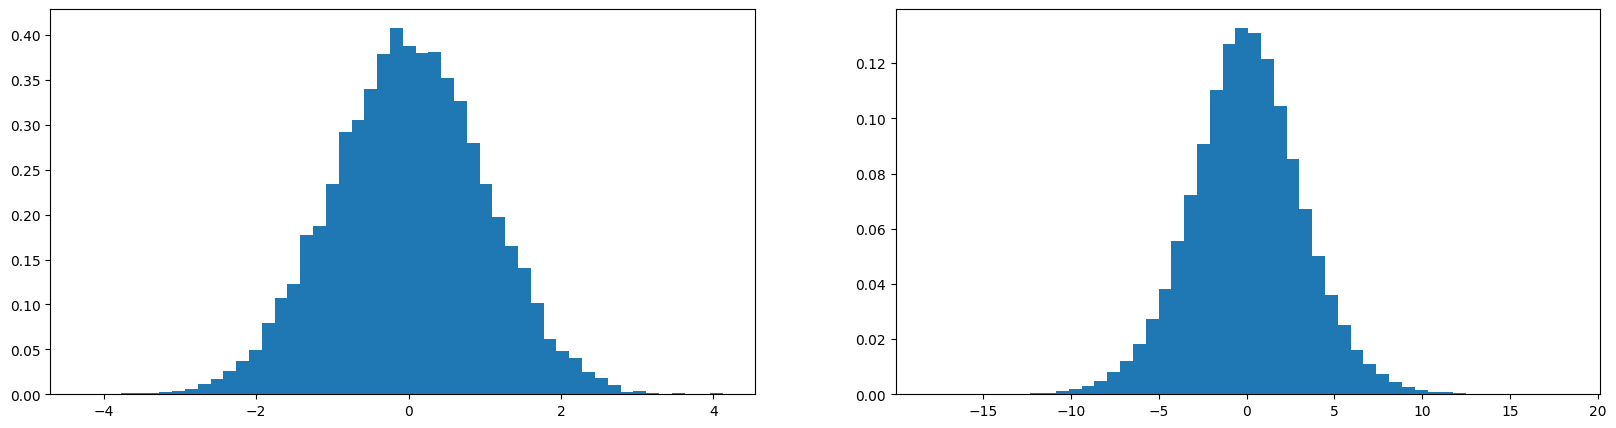

In [34]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(1, 2, 2)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [35]:
(torch.randn(10000) * 0.2).std()

tensor(0.2012)

In [36]:
(5/3) / (30 ** 0.5)

0.3042903097250923

In [39]:
hpreact.shape

torch.Size([32, 200])

In [40]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [43]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [44]:
# BatchNorm
# MLP revisited
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)  # the embedding table
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / (n_embd * block_size) ** 0.5 # gain for tanh
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
# print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    hpreact = (hpreact - hpreact.mean(0, keepdim = True)) / hpreact.std(0, keepdim = True) # Batchnorm
    h = torch.tanh(hpreact)  # hidden layer activation
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 3.3147
  10000/200000: 2.1942
  20000/200000: 2.3443
  30000/200000: 2.4160
  40000/200000: 1.9913
  50000/200000: 2.2978
  60000/200000: 2.5254
  70000/200000: 2.0707
  80000/200000: 2.3107
  90000/200000: 2.0663
 100000/200000: 1.9933
 110000/200000: 2.3179
 120000/200000: 1.9123
 130000/200000: 2.4505
 140000/200000: 2.4321
 150000/200000: 2.2003
 160000/200000: 2.0463
 170000/200000: 1.8839
 180000/200000: 1.9983
 190000/200000: 1.8873


In [46]:
# BatchNorm
# MLP revisited
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)  # the embedding table
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / (n_embd * block_size) ** 0.5 # gain for tanh
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2]
# print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim = True)) / hpreact.std(0, keepdim = True) + bnbias # Batchnorm
    h = torch.tanh(hpreact)  # hidden layer activation
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 3.3147
  10000/200000: 2.1942
  20000/200000: 2.3443
  30000/200000: 2.4160
  40000/200000: 1.9913
  50000/200000: 2.2978
  60000/200000: 2.5254
  70000/200000: 2.0707
  80000/200000: 2.3107
  90000/200000: 2.0663
 100000/200000: 1.9933
 110000/200000: 2.3179
 120000/200000: 1.9123
 130000/200000: 2.4505
 140000/200000: 2.4321
 150000/200000: 2.2003
 160000/200000: 2.0463
 170000/200000: 1.8839
 180000/200000: 1.9983
 190000/200000: 1.8873


In [47]:
# calibrate the batch norm at the end of training
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [48]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.0785984992980957
val 2.1129164695739746


In [49]:
# BatchNorm: robust and fast
# MLP revisited
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)  # the embedding table
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / (n_embd * block_size) ** 0.5 # gain for tanh
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2]
# print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    bnmeani = hpreact.mean(0, keepdim = True)
    bnstdi = hpreact.std(0, keepdim = True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # Batchnorm
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
        
    h = torch.tanh(hpreact)  # hidden layer activation
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 3.3147
  10000/200000: 2.1942
  20000/200000: 2.3443
  30000/200000: 2.4160
  40000/200000: 1.9913
  50000/200000: 2.2978
  60000/200000: 2.5254
  70000/200000: 2.0707
  80000/200000: 2.3107
  90000/200000: 2.0663
 100000/200000: 1.9933
 110000/200000: 2.3179
 120000/200000: 1.9123
 130000/200000: 2.4505
 140000/200000: 2.4321
 150000/200000: 2.2003
 160000/200000: 2.0463
 170000/200000: 1.8839
 180000/200000: 1.9983
 190000/200000: 1.8873


In [50]:
bnmean

tensor([[-2.3177e+00, -3.6403e-01, -1.0247e+00,  1.2613e+00,  1.7141e+00,
          1.0201e+00,  1.9386e+00, -2.2117e+00, -1.2373e-01,  1.3684e-01,
         -1.7104e+00, -1.9277e+00, -8.8307e-01,  6.2152e-01, -2.6556e-01,
         -6.3026e-01,  9.8004e-01, -2.2057e+00,  7.8214e-02,  7.9929e-01,
         -5.3766e-01,  2.7583e-01,  6.1363e-01,  1.3937e+00,  7.1977e-01,
          1.2883e+00,  1.4895e+00, -4.1136e-01,  8.4804e-01,  1.8169e+00,
         -2.1954e-01, -1.3686e+00, -7.3394e-01, -1.0650e+00, -2.0064e-01,
         -1.4059e+00, -1.8569e+00,  6.6707e-01, -8.5582e-01,  8.7047e-01,
          6.2619e-02, -4.5243e-01, -4.9262e-01,  5.2697e-01,  1.1893e+00,
          7.7382e-01,  2.7716e+00, -8.7593e-01,  1.5452e+00,  1.3719e+00,
          8.8825e-01, -2.3543e-03,  1.7612e+00,  1.3297e+00,  9.8162e-01,
         -1.8444e+00, -1.6665e-01,  6.6284e-01,  2.0306e+00, -2.8664e+00,
         -4.7368e-01,  5.8871e-01,  7.6712e-02,  6.2639e-01,  2.2087e+00,
          1.2394e+00, -3.6638e-01,  1.

In [51]:
bnmean_running

tensor([[-2.3445e+00, -3.5032e-01, -1.0127e+00,  1.2629e+00,  1.7157e+00,
          1.0086e+00,  1.9284e+00, -2.2175e+00, -1.2663e-01,  1.3020e-01,
         -1.7290e+00, -1.9392e+00, -8.8939e-01,  6.0991e-01, -2.6687e-01,
         -6.0494e-01,  9.8813e-01, -2.2140e+00,  6.0802e-02,  7.7774e-01,
         -5.3135e-01,  2.8868e-01,  6.0594e-01,  1.3920e+00,  7.1695e-01,
          1.2921e+00,  1.5023e+00, -4.1434e-01,  8.3973e-01,  1.8148e+00,
         -2.3546e-01, -1.3639e+00, -7.2678e-01, -1.0638e+00, -1.9584e-01,
         -1.4107e+00, -1.8722e+00,  6.5585e-01, -8.4153e-01,  8.7342e-01,
          4.7286e-02, -4.7717e-01, -4.9640e-01,  5.2343e-01,  1.2032e+00,
          7.9042e-01,  2.7750e+00, -8.7957e-01,  1.5351e+00,  1.3743e+00,
          8.7428e-01, -8.4206e-03,  1.7559e+00,  1.3274e+00,  9.8033e-01,
         -1.8463e+00, -1.6473e-01,  6.5881e-01,  2.0454e+00, -2.8682e+00,
         -4.9856e-01,  5.8613e-01,  6.3052e-02,  6.2297e-01,  2.2022e+00,
          1.2326e+00, -3.7525e-01,  1.

In [52]:
bnstd

tensor([[2.5774, 2.0526, 2.3618, 2.1369, 2.1846, 2.4584, 2.0466, 2.3757, 2.1037,
         2.1399, 2.6536, 2.3401, 2.0661, 2.2608, 2.1886, 2.6695, 2.4102, 1.9025,
         2.3227, 2.2686, 2.1171, 2.4492, 2.2325, 2.2913, 2.2250, 2.1668, 2.2751,
         2.2800, 2.3116, 2.4338, 1.9600, 1.9801, 2.2561, 2.2626, 2.2726, 2.3296,
         4.0039, 2.3622, 2.9114, 1.9598, 2.0984, 2.1730, 2.3465, 2.1367, 2.3041,
         2.5543, 2.1177, 2.7289, 2.1559, 2.6261, 2.1664, 2.0403, 2.1289, 1.9327,
         2.1018, 2.3091, 2.0403, 2.1755, 2.9706, 1.8855, 2.1296, 2.1919, 2.0179,
         2.2901, 2.3282, 2.1779, 2.0830, 2.5356, 2.2903, 2.2408, 2.3152, 2.0731,
         1.9556, 2.2118, 1.9390, 1.8939, 2.5302, 2.5021, 1.9014, 2.1166, 2.3604,
         2.1534, 2.1011, 2.2480, 2.6945, 2.3391, 2.0747, 2.4778, 2.4693, 2.6975,
         2.0789, 2.0609, 2.3381, 2.1191, 2.2821, 2.2375, 2.2179, 2.0186, 1.9854,
         2.1641, 1.9188, 2.2278, 2.0187, 2.1472, 2.0475, 2.2218, 2.0836, 2.2195,
         2.1102, 2.2886, 2.2

In [53]:
bnstd_running

tensor([[2.5580, 2.0259, 2.3437, 2.0971, 2.1464, 2.4192, 2.0358, 2.3379, 2.0753,
         2.1125, 2.6360, 2.3071, 2.0328, 2.2406, 2.1564, 2.6491, 2.3797, 1.8880,
         2.2961, 2.2555, 2.0928, 2.4227, 2.2089, 2.2715, 2.1994, 2.1408, 2.2422,
         2.2530, 2.2899, 2.3981, 1.9297, 1.9795, 2.2543, 2.2400, 2.2635, 2.3003,
         3.9886, 2.3289, 2.8939, 1.9369, 2.0768, 2.1449, 2.3070, 2.1090, 2.2740,
         2.5338, 2.0946, 2.6712, 2.1303, 2.6143, 2.1326, 2.0205, 2.1046, 1.9140,
         2.0781, 2.2856, 2.0190, 2.1540, 2.9517, 1.8699, 2.1071, 2.1764, 2.0069,
         2.2686, 2.3052, 2.1526, 2.0627, 2.5060, 2.2668, 2.2101, 2.2896, 2.0534,
         1.9384, 2.1881, 1.9209, 1.8762, 2.5127, 2.4779, 1.8812, 2.1026, 2.3317,
         2.1260, 2.0704, 2.2261, 2.6732, 2.2952, 2.0393, 2.4467, 2.4558, 2.6842,
         2.0571, 2.0345, 2.3218, 2.0948, 2.2767, 2.2084, 2.1994, 2.0006, 1.9556,
         2.1482, 1.9118, 2.2046, 1.9926, 2.1346, 2.0226, 2.1964, 2.0625, 2.1777,
         2.0909, 2.2477, 2.2

In [54]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.078073024749756
val 2.1128151416778564


In [57]:
# BatchNorm: robust and fast
# drop b1
# MLP revisited
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)  # the embedding table
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / (n_embd * block_size) ** 0.5 # gain for tanh
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
# print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 # + b1  # hidden layer pre-activation
    # BatchNorm
    bnmeani = hpreact.mean(0, keepdim = True)
    bnstdi = hpreact.std(0, keepdim = True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # Batchnorm
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    # Non-linear activation
    h = torch.tanh(hpreact)  # hidden layer activation
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 3.3147
  10000/200000: 2.1984
  20000/200000: 2.3375
  30000/200000: 2.4359
  40000/200000: 2.0119
  50000/200000: 2.2595
  60000/200000: 2.4775
  70000/200000: 2.1020
  80000/200000: 2.2788
  90000/200000: 2.1862
 100000/200000: 1.9474
 110000/200000: 2.3010
 120000/200000: 1.9837
 130000/200000: 2.4523
 140000/200000: 2.3839
 150000/200000: 2.1987
 160000/200000: 1.9733
 170000/200000: 1.8668
 180000/200000: 1.9973
 190000/200000: 1.8347


In [58]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 #+ b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.06659197807312
val 2.1050572395324707


In [59]:
# torch.nn.BatchNorm1d()
# SUMMARY

In [61]:
# Let's train a deeper network
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass        
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize the unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(), # if no tanh(), diffuse gradients and make training unstable
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # important
            
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

46497


In [69]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    # break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 1.7051
  10000/200000: 1.9263
  20000/200000: 1.6804
  30000/200000: 1.8373
  40000/200000: 2.5355
  50000/200000: 1.6076
  60000/200000: 2.5225
  70000/200000: 2.4140
  80000/200000: 2.3300
  90000/200000: 2.2932
 100000/200000: 2.3362
 110000/200000: 1.9505
 120000/200000: 1.8451
 130000/200000: 1.8059
 140000/200000: 2.3715
 150000/200000: 2.2061
 160000/200000: 2.0353
 170000/200000: 2.1471
 180000/200000: 1.6273
 190000/200000: 2.4318


layer 1 (      Tanh): mean -0.02, std 0.89, saturated: 57.66%
layer 3 (      Tanh): mean -0.02, std 0.91, saturated: 62.94%
layer 5 (      Tanh): mean -0.00, std 0.93, saturated: 65.62%
layer 7 (      Tanh): mean -0.06, std 0.93, saturated: 66.78%
layer 9 (      Tanh): mean +0.03, std 0.85, saturated: 41.50%


Text(0.5, 1.0, 'activation distribution')

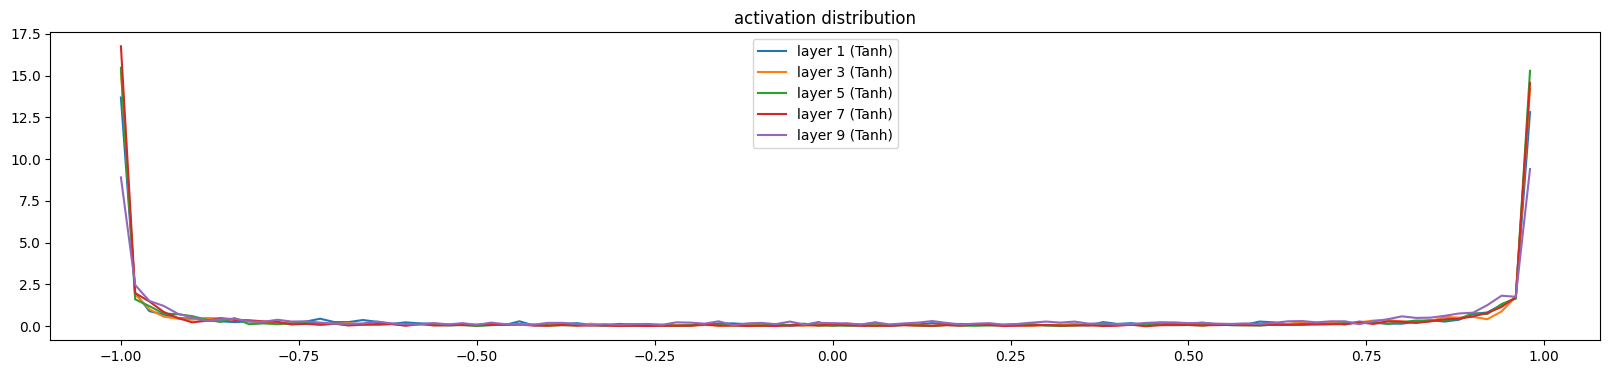

In [70]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the last layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 1 (      Tanh): mean +0.000094, std 4.737688e-03
layer 3 (      Tanh): mean -0.000023, std 3.902795e-03
layer 5 (      Tanh): mean -0.000099, std 4.215090e-03
layer 7 (      Tanh): mean -0.000093, std 4.696435e-03
layer 9 (      Tanh): mean +0.000079, std 4.806737e-03


Text(0.5, 1.0, 'gradient distribution')

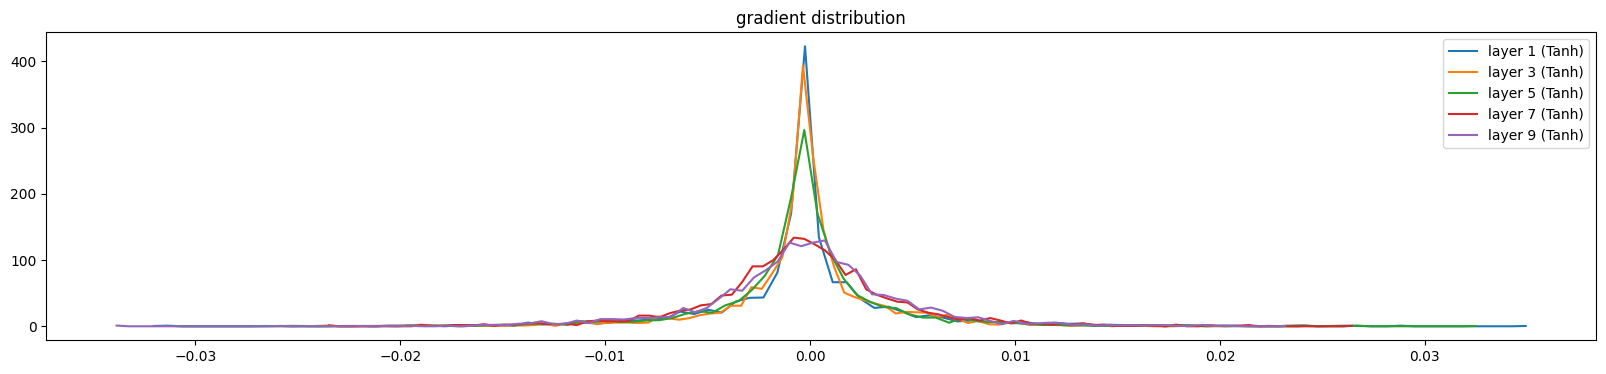

In [72]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the last layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean().item(), t.std().item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000082 | std 2.138834e-02 | grad: data ratio 1.776045e-02
weight  (30, 100) | mean -0.000029 | std 1.218142e-02 | grad: data ratio 2.167198e-02
weight (100, 100) | mean -0.000017 | std 6.956219e-03 | grad: data ratio 2.061872e-02
weight (100, 100) | mean +0.000053 | std 5.891418e-03 | grad: data ratio 1.840281e-02
weight (100, 100) | mean -0.000027 | std 6.779528e-03 | grad: data ratio 2.174805e-02
weight (100, 100) | mean -0.000028 | std 8.442781e-03 | grad: data ratio 3.178586e-02
weight  (100, 27) | mean +0.000000 | std 2.471164e-02 | grad: data ratio 1.191295e-01


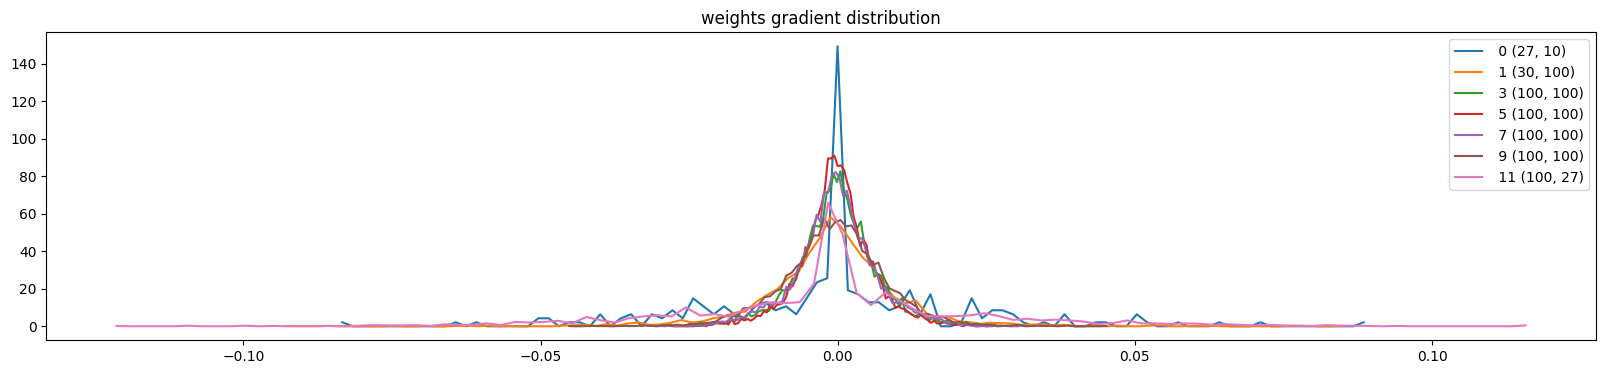

In [74]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2: 
        print('weight %10s | mean %+f | std %e | grad: data ratio %e' % (tuple(p.shape), t.mean().item(), t.std().item(), (t.std() / p.std()).item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f' {i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

In [75]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

# put layers into eval mode
for layer in layers:
    layer.training = False
split_loss('train')
split_loss('val')

ValueError: Expected input batch_size (32) to match target batch_size (182625).

In [81]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
        
    if i >= 1000:
        break
    
    # break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 2.0172


layer 1 (      Tanh): mean -0.05, std 0.89, saturated: 58.75%
layer 3 (      Tanh): mean +0.01, std 0.91, saturated: 63.63%
layer 5 (      Tanh): mean -0.02, std 0.93, saturated: 64.81%
layer 7 (      Tanh): mean -0.09, std 0.93, saturated: 66.81%
layer 9 (      Tanh): mean +0.01, std 0.85, saturated: 40.53%


Text(0.5, 1.0, 'activation distribution')

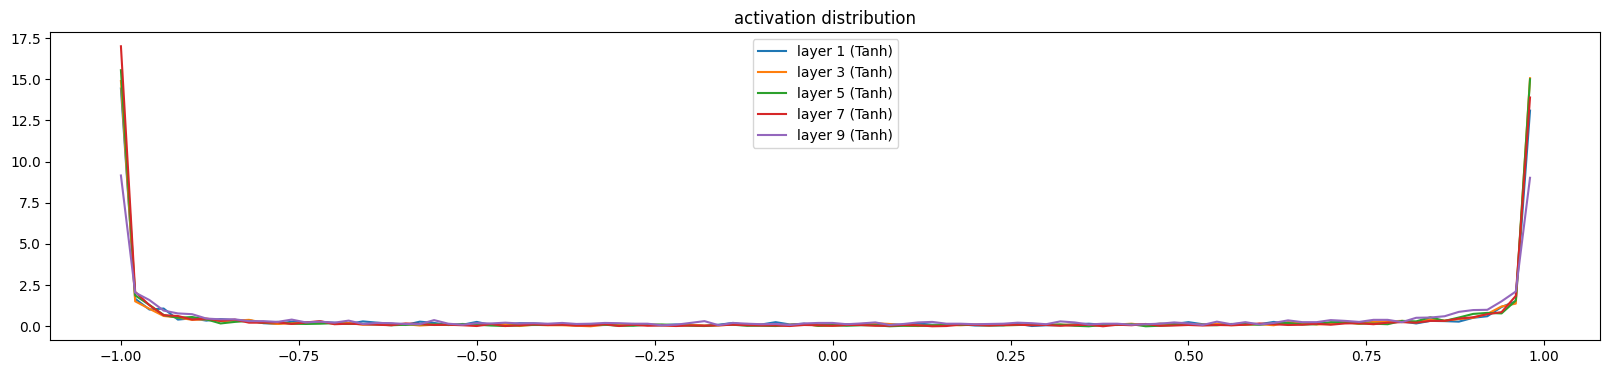

In [82]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the last layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (
        i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 1 (      Tanh): mean -0.000066, std 3.411882e-03
layer 3 (      Tanh): mean +0.000014, std 3.752087e-03
layer 5 (      Tanh): mean -0.000014, std 3.573981e-03
layer 7 (      Tanh): mean -0.000065, std 4.019763e-03
layer 9 (      Tanh): mean -0.000073, std 4.738586e-03


Text(0.5, 1.0, 'gradient distribution')

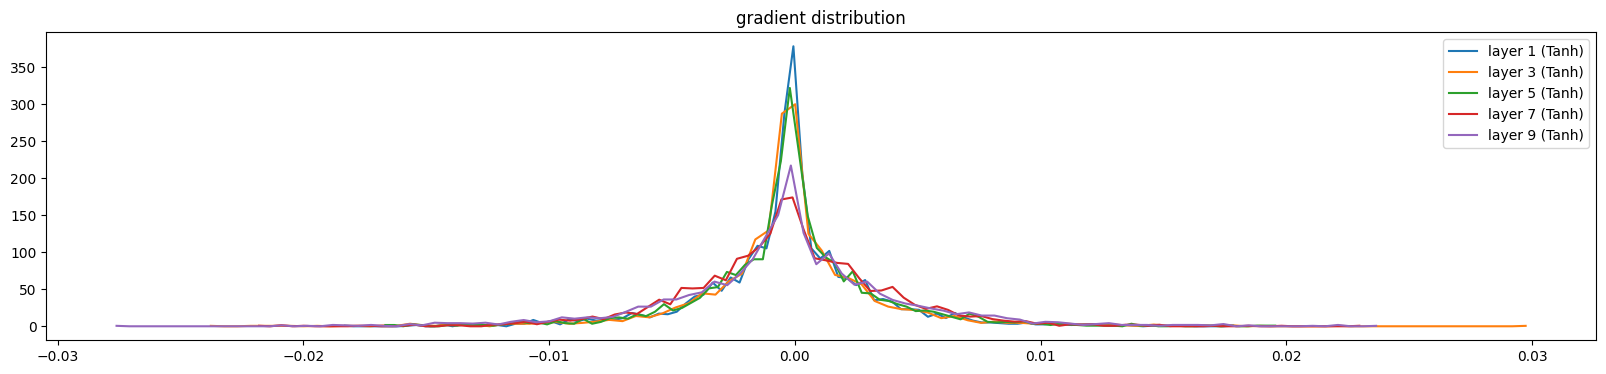

In [83]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the last layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean().item(), t.std().item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000323 | std 1.387032e-02 | grad: data ratio 1.151496e-02
weight  (30, 100) | mean -0.000129 | std 7.591092e-03 | grad: data ratio 1.345702e-02
weight (100, 100) | mean +0.000037 | std 4.846584e-03 | grad: data ratio 1.431077e-02
weight (100, 100) | mean -0.000126 | std 5.858103e-03 | grad: data ratio 1.823520e-02
weight (100, 100) | mean -0.000012 | std 5.842138e-03 | grad: data ratio 1.867549e-02
weight (100, 100) | mean +0.000026 | std 6.888809e-03 | grad: data ratio 2.586109e-02
weight  (100, 27) | mean +0.000000 | std 2.574186e-02 | grad: data ratio 1.271319e-01


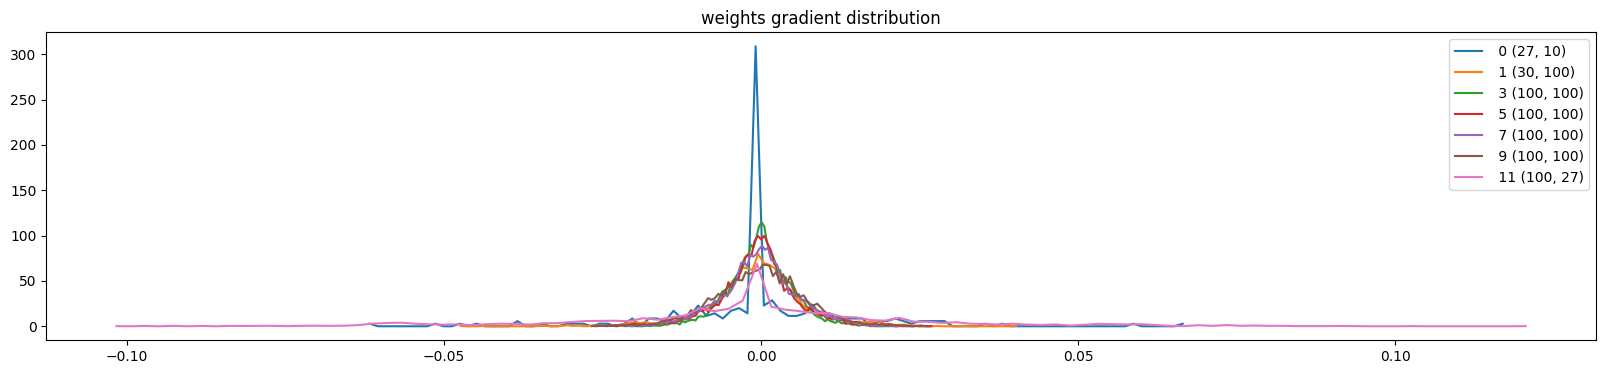

In [84]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad: data ratio %e' % (
        tuple(p.shape), t.mean().item(), t.std().item(), (t.std() / p.std()).item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f' {i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

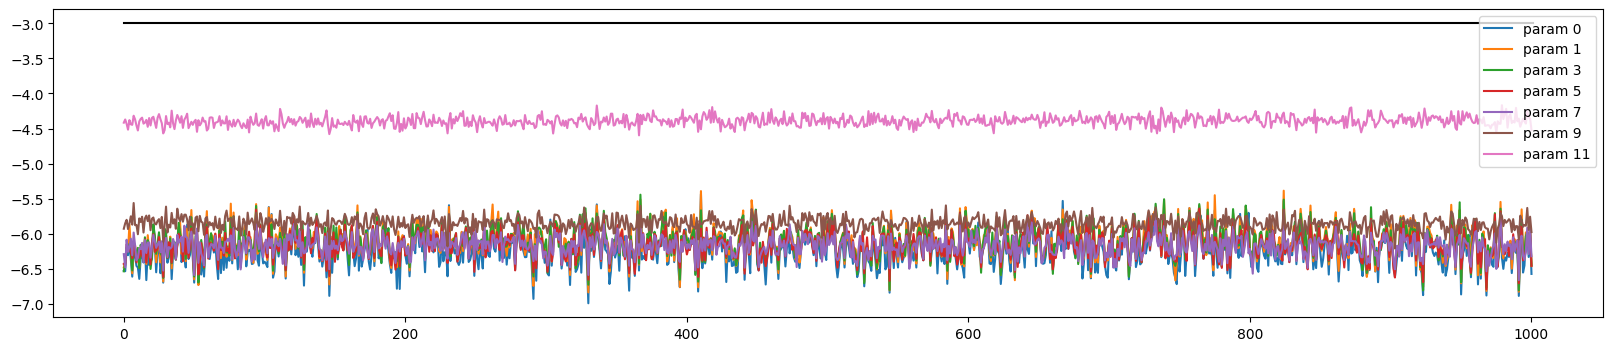

In [80]:
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends)
# if learning rate is higher, the ratios would be higher. We want to be in a good range for these ratios to ensure stable training.

In [85]:
# Let's train a deeper network
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass        
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize the unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # important
            
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

47551


In [86]:
# same forward pass as before
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X and Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
        
    if i >= 1000:
        break
    
    # break # AFTER_DEBUG: would take out obviously to run full optimization

      0/200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.62%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.47%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.16%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.81%
layer 14 (      Tanh): mean -0.00, std 0.65, saturated: 1.78%


Text(0.5, 1.0, 'activation distribution')

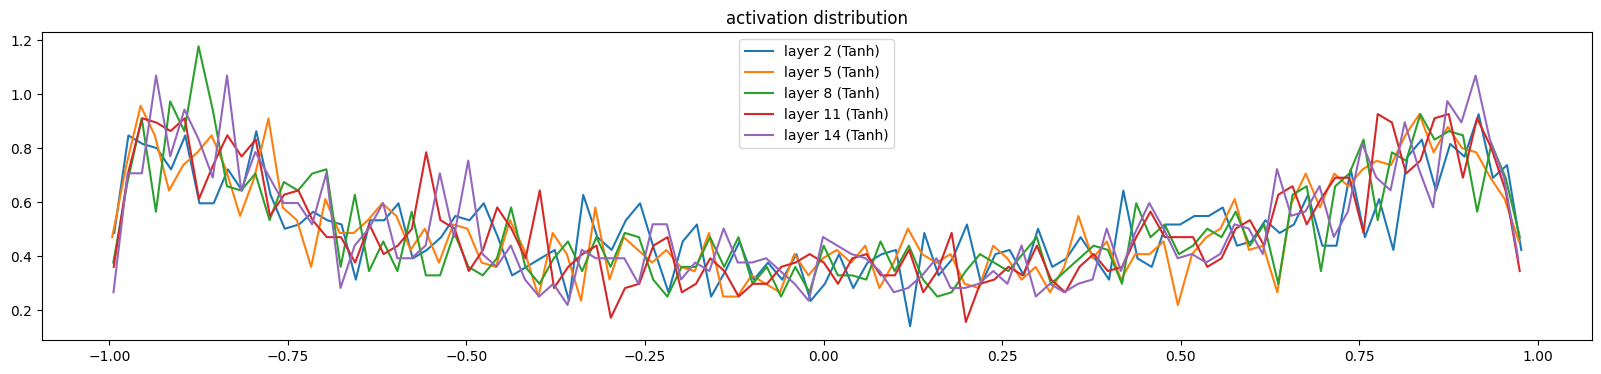

In [87]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the last layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (
        i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 3.682950e-03
layer 5 (      Tanh): mean -0.000000, std 3.262607e-03
layer 8 (      Tanh): mean -0.000000, std 2.973728e-03
layer 11 (      Tanh): mean +0.000000, std 2.741108e-03
layer 14 (      Tanh): mean +0.000000, std 2.584293e-03


Text(0.5, 1.0, 'gradient distribution')

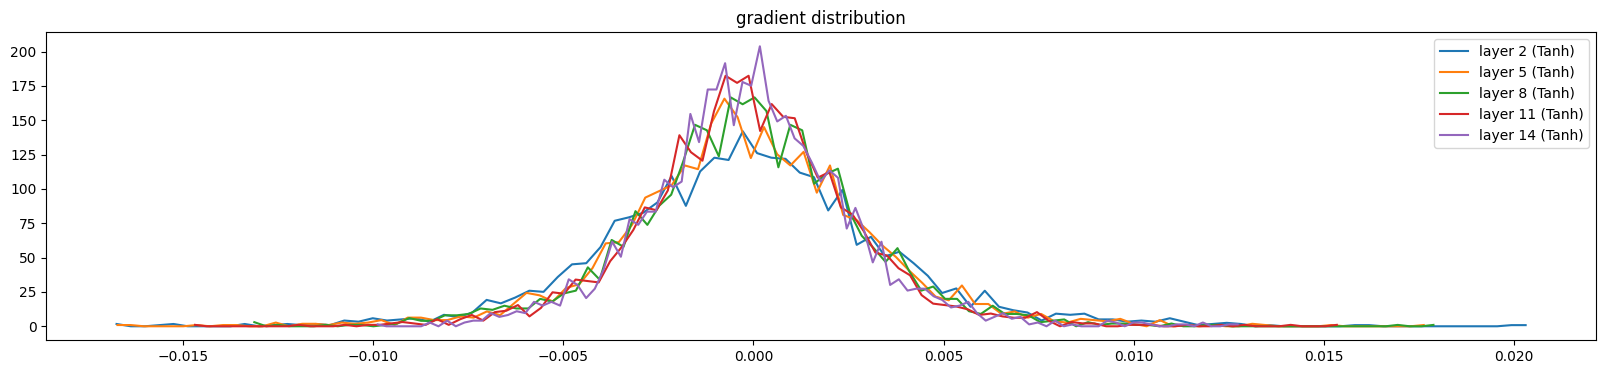

In [88]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the last layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean().item(), t.std().item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.019883e-02 | grad: data ratio 1.018844e-02
weight  (30, 100) | mean +0.000092 | std 8.238423e-03 | grad: data ratio 2.635837e-02
weight (100, 100) | mean +0.000031 | std 7.318103e-03 | grad: data ratio 4.377139e-02
weight (100, 100) | mean -0.000019 | std 6.662023e-03 | grad: data ratio 3.949895e-02
weight (100, 100) | mean -0.000019 | std 5.821514e-03 | grad: data ratio 3.468160e-02
weight (100, 100) | mean +0.000053 | std 5.445293e-03 | grad: data ratio 3.243365e-02
weight  (100, 27) | mean -0.000165 | std 1.046844e-02 | grad: data ratio 6.281258e-02


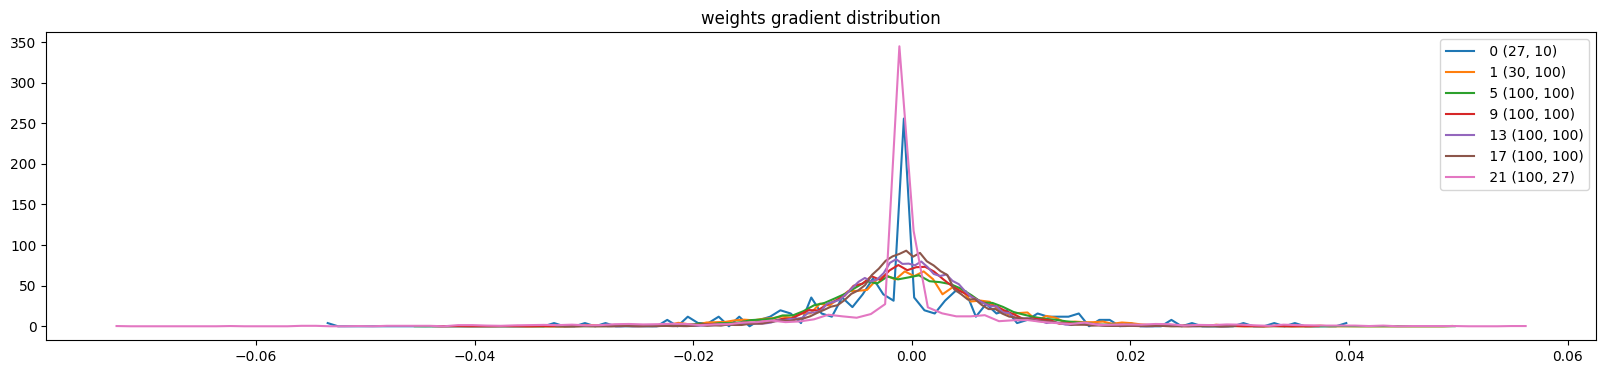

In [89]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad: data ratio %e' % (
        tuple(p.shape), t.mean().item(), t.std().item(), (t.std() / p.std()).item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f' {i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

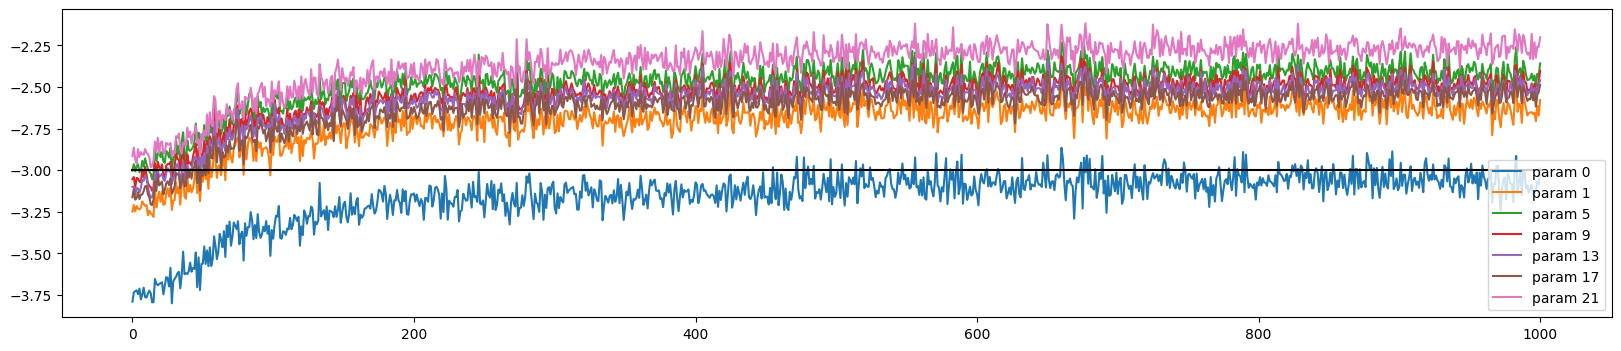

In [90]:
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends)
# if gain is lower, the ratio will be higher.